In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "--force-reinstall", "opencv-python-headless==4.9.0.80"])

CompletedProcess(args=['pip', 'install', '-q', '--force-reinstall', 'opencv-python-headless==4.9.0.80'], returncode=0)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -r /content/drive/MyDrive/FAIML-RL-26-main/requirements.txt -q

%cd /content/drive/MyDrive/FAIML-RL-26-main/part2/panda-gym
!pip install -e .

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/FAIML-RL-26-main/part2/panda-gym
Obtaining file:///content/drive/MyDrive/FAIML-RL-26-main/part2/panda-gym
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: panda_gym
    Found existing installation: panda_gym 3.0.8
    Uninstalling panda_gym-3.0.8:
      Successfully uninstalled panda_gym-3.0.8
  Running setup.py develop for panda_gym
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [3]:
from collections import deque

import gymnasium as gym
import numpy as np
import panda_gym  # type: ignore[import-not-found]
#from stable_baselines3 import DDPG
#from rand_wrapper import RandomizationWrapper
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, CallbackList
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
import gymnasium as gym

class RandomizationWrapper(gym.Wrapper):
    """
    Wrapper that applies randomization to the environment.
    """
    def __init__(
        self,
        env,
        mass_range=(1.0, 1.0),
        mode="none",
    ):
        super().__init__(env)

        self.mode = mode
        self.mass_min_limit, self.mass_max_limit = mass_range

        # global limits
        # self.mass_min_limit, self.mass_max_limit = mass_range

        self.last_sample_type = None  # 'min', 'max', or 'uniform'
        self.adr_successes = []       # boundary episodes results list
        self.adr_buffer_size = 50     # must wait boundary episodes before deciding
        self.adr_target_success = 0.6 # treshold
        self.adr_delta = 0.05         # how much we can change the range after the attempt

    # -----------------------
    # Mass Sampling
    # -----------------------

    def _sample_mass(self):

        if self.mode == "none":
            return None

        elif self.mode == "udr":
            return np.random.uniform(self.mass_min_limit, self.mass_max_limit)

        elif self.mode == "adr":
            if np.random.random() < 0.5:
                if np.random.random() < 0.5:
                    self.last_sample_type = 'min'
                    return self.mass_min_limit
                else:
                    self.last_sample_type = 'max'
                    return self.mass_max_limit
            else:
                self.last_sample_type = 'uniform'
                return np.random.uniform(self.mass_min_limit, self.mass_max_limit)

        else:
            raise NotImplementedError(f"Sampling strategy '{self.mode}' is not implemented yet.")

    def step(self, action):

        obs, reward, terminated, truncated, info = self.env.step(action)

        done = terminated or truncated

        # Optionally, you can add here extra logic
        if self.mode=="adr" and done:
          success = info.get('is_success', 0.0)

          if self.last_sample_type != 'uniform':
            self.adr_successes.append(float(success))

            if len(self.adr_successes) >= self.adr_buffer_size:
              # Calculate the mean success rate of the last 50 boundary episodes
              avg_success = np.mean(self.adr_successes[-self.adr_buffer_size:])
              if avg_success > self.adr_target_success:
                  # Model is OK → Enlarge the interval
                  if self.last_sample_type == 'min':
                      self.mass_min_limit = max(0.1, self.mass_min_limit - self.adr_delta)
                  else:
                      self.mass_max_limit = self.mass_max_limit + self.adr_delta
              else:
                  if self.last_sample_type == 'min':
                      self.mass_min_limit = min(self.mass_min_limit + self.adr_delta, self.mass_max_limit - 0.1)
                  else:
                      self.mass_max_limit = max(self.mass_max_limit - self.adr_delta, self.mass_min_limit + 0.1)

        return obs, reward, terminated, truncated, info

    # -----------------------
    # Reset
    # -----------------------

    def reset(self, **kwargs):

        new_mass = self._sample_mass()

        if new_mass is not None:

            sim = self.env.unwrapped.task.sim
            object_body_id = sim._bodies_idx["object"]

            sim.physics_client.changeDynamics(
                bodyUniqueId=object_body_id,
                linkIndex=-1,
                mass=float(new_mass),
            )

            print(
                f"[{self.mode}] mass={new_mass:.2f} "
                f"range=[{self.mass_min_limit:.2f},{self.mass_max_limit:.2f}] "
                f"type={self.last_sample_type}"
            )

        return super().reset(**kwargs)

In [5]:
def main() -> None:
    #args = parse_args()
    mode = "adr"                  # or mode="udr"
    exp_name = "adr_0.8_1.2"      # or adr_xxx_xxx
    env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="source",
        reward_type="dense",
    )

    eval_env = gym.make(
        "PandaPush-v3",
        render_mode="rgb_array",
        type="source",
        reward_type="dense",
    )

    checkpoint_callback = CheckpointCallback(
      save_freq=50000,
      save_path=f"/content/drive/MyDrive/FAIML-RL-26-main/checkpoints/{exp_name}/",
      name_prefix=exp_name,
      save_replay_buffer=True,
    )

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"/content/drive/MyDrive/FAIML-RL-26-main/evalcallback/{exp_name}/",
        log_path=f"/content/drive/MyDrive/FAIML-RL-26-main/evalcallback/{exp_name}/",
        eval_freq=50000,
        n_eval_episodes=20,
        deterministic=True,
        verbose=1,
    )

    #TODO: add randomization wrapper here
    env=RandomizationWrapper(env, mass_range=(0.8,1.2), mode=f"{mode}")

    # trainings done :
      # udr with range (0.5,6.0)
      # train with con range (0.5,8.0)
      # train with con range (0.8,1.2)

    #TODO: create model and train it
    model = SAC("MultiInputPolicy", env, verbose=1, seed=42, batch_size=512, device="cuda")
    model.learn(total_timesteps=500000, callback=CallbackList([checkpoint_callback, eval_callback]))

    #we print the final range only for adr to see how much we changed the range
    if mode == "adr":
      print("Final ADR range:")
      print(env.mass_min_limit, env.mass_max_limit)

    save_name = f"sac_push_{exp_name}_500000"
    # TODO: model.save(save_name)
    model.save(f"/content/drive/MyDrive/FAIML-RL-26-main/results/{exp_name}/{save_name}")


In [ ]:
if __name__ == "__main__":
    main()

Created object with mass: 1.0
Created object with mass: 1.0
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[adr] mass=1.20 range=[0.80,1.20] type=max
[adr] mass=1.04 range=[0.80,1.20] type=uniform


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Output streaming troncato alle ultime 5000 righe.
|    critic_loss     | 0.0698   |
|    ent_coef        | 0.0202   |
|    ent_coef_loss   | -12.2    |
|    learning_rate   | 0.0003   |
|    n_updates       | 13411    |
---------------------------------
[adr] mass=0.95 range=[0.85,0.95] type=max
[adr] mass=0.95 range=[0.85,0.95] type=max
[adr] mass=0.85 range=[0.85,0.95] type=min
[adr] mass=0.85 range=[0.85,0.95] type=min
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 38.7     |
|    ep_rew_mean     | -3.49    |
|    success_rate    | 0.23     |
| time/              |          |
|    episodes        | 344      |
|    fps             | 17       |
|    time_elapsed    | 778      |
|    total_timesteps | 13614    |
| train/             |          |
|    actor_loss      | -10.9    |
|    critic_loss     | 0.0352   |
|    ent_coef        | 0.0197   |
|    ent_coef_loss   | -12.8    |
|    learning_rate   | 0.0003   |
|    n_updates       | 13513  

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Output streaming troncato alle ultime 5000 righe.
|    critic_loss     | 0.216    |
|    ent_coef        | 0.00715  |
|    ent_coef_loss   | -0.149   |
|    learning_rate   | 0.0003   |
|    n_updates       | 479059   |
---------------------------------
[adr] mass=0.94 range=[0.30,5.30] type=uniform
[adr] mass=0.30 range=[0.30,5.30] type=min
[adr] mass=0.28 range=[0.25,5.30] type=uniform
[adr] mass=0.25 range=[0.25,5.30] type=min
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 19.9     |
|    ep_rew_mean     | -1.68    |
|    success_rate    | 0.74     |
| time/              |          |
|    episodes        | 13716    |
|    fps             | 17       |
|    time_elapsed    | 27951    |
|    total_timesteps | 479237   |
| train/             |          |
|    actor_loss      | 6.56     |
|    critic_loss     | 0.314    |
|    ent_coef        | 0.00709  |
|    ent_coef_loss   | 0.695    |
|    learning_rate   | 0.0003   |
|    n_updates       |

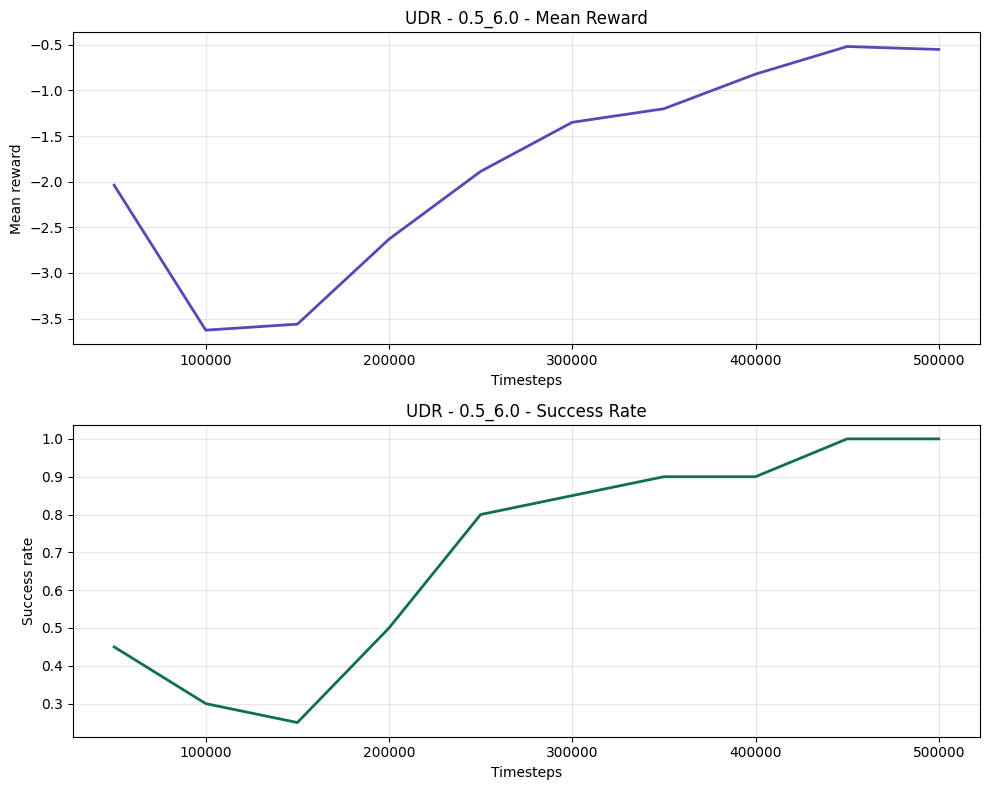

In [6]:
# PLOT -> UDR in range[0.5,6.0]
data = np.load("/content/drive/MyDrive/FAIML-RL-26-main/evalcallback/udr_0.5_6.0/evaluations.npz")

timesteps = data['timesteps']
mean_rewards = data['results'].mean(axis=1)
success_rates = data['successes'].mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(timesteps, mean_rewards, color='#534AB7', linewidth=2)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Mean reward')
ax1.set_title('UDR - 0.5_6.0 - Mean Reward')
ax1.grid(True, alpha=0.3)

ax2.plot(timesteps, success_rates, color='#0F6E56', linewidth=2)
ax2.set_xlabel('Timesteps')
ax2.set_ylabel('Success rate')
ax2.set_title('UDR - 0.5_6.0 - Success Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FAIML-RL-26-main/results/udr_0.5_6.0/learning_curve.png", dpi=150)
plt.show()

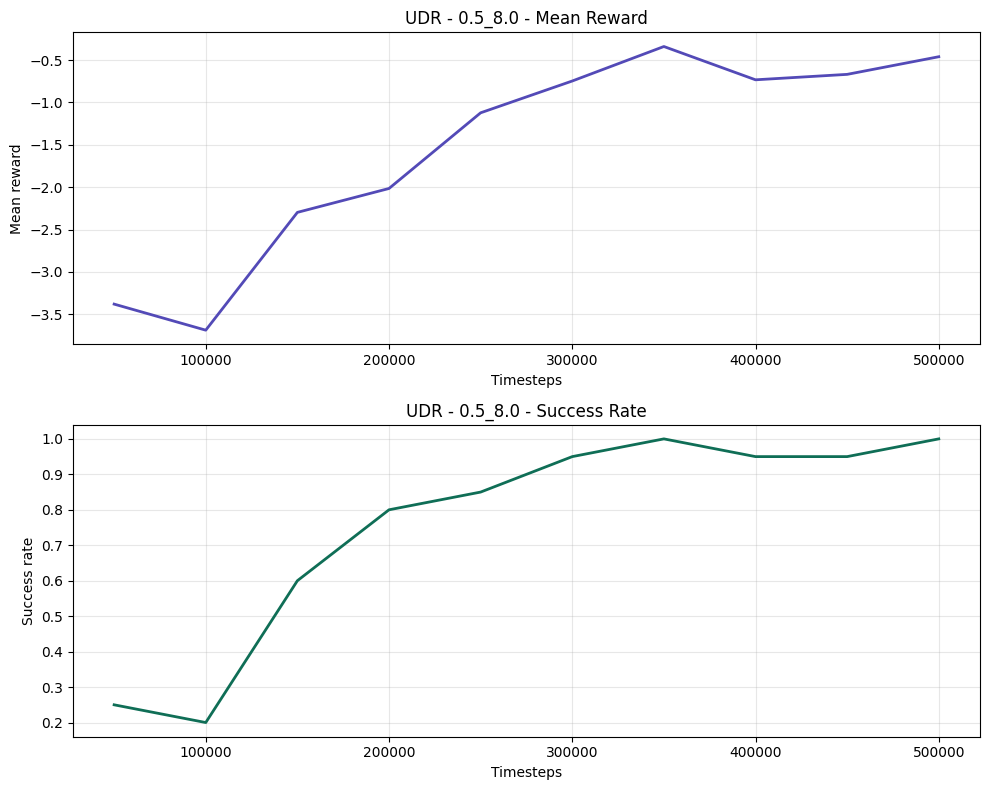

In [7]:
# PLOT -> UDR in range[0.5,8.0]
data = np.load("/content/drive/MyDrive/FAIML-RL-26-main/evalcallback/udr_0.5_8.0/evaluations.npz")

timesteps = data['timesteps']
mean_rewards = data['results'].mean(axis=1)
success_rates = data['successes'].mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(timesteps, mean_rewards, color='#534AB7', linewidth=2)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Mean reward')
ax1.set_title('UDR - 0.5_8.0 - Mean Reward')
ax1.grid(True, alpha=0.3)

ax2.plot(timesteps, success_rates, color='#0F6E56', linewidth=2)
ax2.set_xlabel('Timesteps')
ax2.set_ylabel('Success rate')
ax2.set_title('UDR - 0.5_8.0 - Success Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FAIML-RL-26-main/results/udr_0.5_8.0/learning_curve.png", dpi=150)
plt.show()

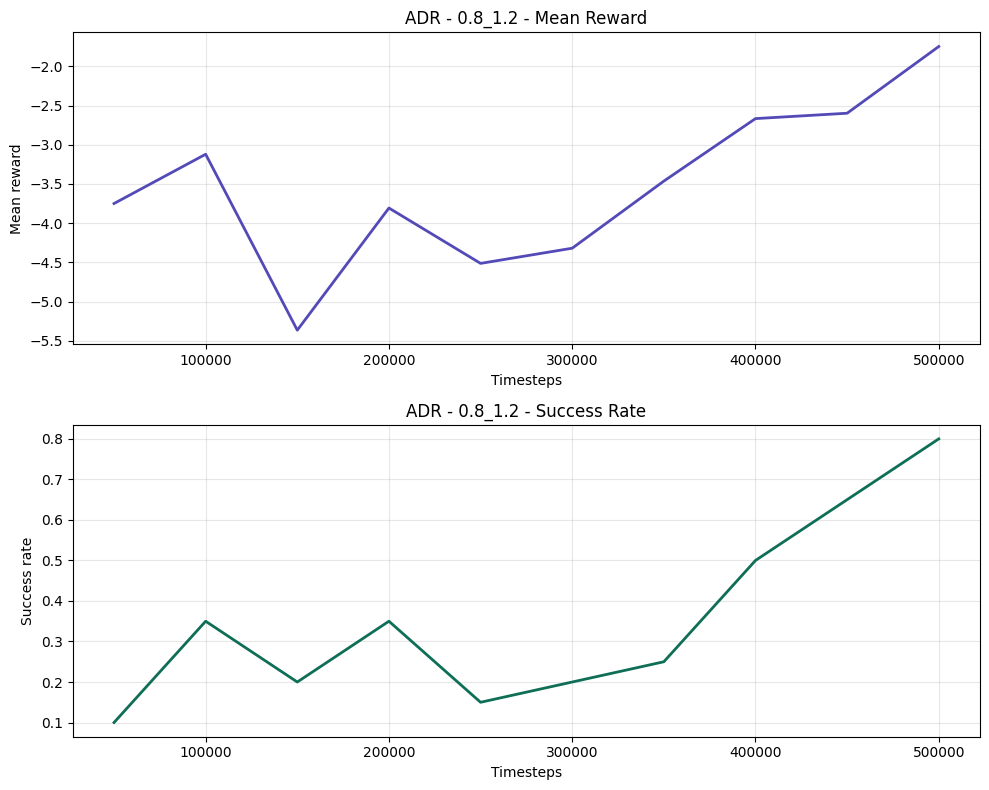

In [8]:
# PLOT -> ADR in range[0.8,1.2]
data = np.load("/content/drive/MyDrive/FAIML-RL-26-main/evalcallback/adr_0.8_1.2/evaluations.npz")

timesteps = data['timesteps']
mean_rewards = data['results'].mean(axis=1)
success_rates = data['successes'].mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(timesteps, mean_rewards, color='#534AB7', linewidth=2)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Mean reward')
ax1.set_title('ADR - 0.8_1.2 - Mean Reward')
ax1.grid(True, alpha=0.3)

ax2.plot(timesteps, success_rates, color='#0F6E56', linewidth=2)
ax2.set_xlabel('Timesteps')
ax2.set_ylabel('Success rate')
ax2.set_title('ADR - 0.8_1.2 - Success Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FAIML-RL-26-main/results/adr_0.8_1.2/learning_curve.png", dpi=150)
plt.show()